Evaluate direct, CFM, MFM (?) models in generative dropout exp. To eval a given method:
- Load a surrogate model (there are 20 seeds each)
- Load training data, for the timepoints at t=0 and t=0.505
- Load eval data at times t = 0.101, 0.202, 0.303, 0.404, 0.606, 0.707, 0.808, 0.909
- Generate pushforwards at times t = 0.101, 0.202, 0.303, 0.404, 0.606, 0.707, 0.808, 0.909
- Calculate wasserstein distance for each time, and the avg. wasserstein across times

In [55]:
import torch
import numpy as np
import ot
from torch import nn, Tensor
from flow_matching.solver import ODESolver
from flow_matching.utils import ModelWrapper

In [3]:
def compute_wasserstein_distance(samples1, samples2):
    """
    Compute Wasserstein distance between two sets of samples using POT library.
    
    Args:
        samples1: JAX array of shape (n_samples1, dim) or numpy array
        samples2: JAX array of shape (n_samples2, dim) or numpy array
        
    Returns:
        float: The Wasserstein distance
    """
    # Convert from JAX arrays to numpy for POT library compatibility
    samples1_np = np.array(samples1)
    samples2_np = np.array(samples2)
    

    M = ot.dist(samples1_np, samples2_np)
    a = np.ones(samples1_np.shape[0]) / samples1_np.shape[0]  # uniform weights
    b = np.ones(samples2_np.shape[0]) / samples2_np.shape[0]  # uniform weights
        
    return float(ot.emd2(a, b, M))

In [57]:
dropout_data = torch.load('../NLOT/data/diffusion_2moons_dropout.pt')
t0_samples = dropout_data[0]
t05_samples = dropout_data[5]

t0_ambient = t0_samples[:,:2]
t0_condition = t0_samples[:,2:]

t05_ambient = t05_samples[:,:2]
t05_condition = t05_samples[:,2:]

eval_samples = dropout_data[[1,2,3,4,6,7,8,9]]
index_to_eval_time = {0: 0.101, 1: 0.202, 2: 0.303, 3: 0.404, 4: 0.606, 5: 0.707, 6: 0.808, 7: 0.909}

In [12]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [50]:
def print_results(results, name):
    mean = np.mean(results)
    std = np.std(results)
    ci = 1.96 * std / np.sqrt(len(results))
    print(f"{name}: {mean:.3f} ± {ci:.3f}")

# Direct method

In [58]:
class Swish(nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self, x: Tensor) -> Tensor: 
        return torch.sigmoid(x) * x

# Model class with FiLM conditioning
class FiLMMLP(nn.Module):
    def __init__(self, input_dim: int = 2, time_dim: int = 1, hidden_dim: int = 128, cond_dim: int = 1):
        super().__init__()
        
        self.input_dim = input_dim
        self.time_dim = time_dim
        self.hidden_dim = hidden_dim
        self.cond_dim = cond_dim
        
        # Main network layers
        self.input_layer = nn.Linear(input_dim + time_dim, hidden_dim)
        self.hidden_layers = nn.ModuleList([
            nn.Linear(hidden_dim, hidden_dim) for _ in range(3)
        ])
        self.output_layer = nn.Linear(hidden_dim, input_dim)
        
        self.activation = Swish()
        
        # FiLM generator network
        # It will generate gammas and betas for the 4 layers (input + 3 hidden)
        num_film_layers = len(self.hidden_layers) + 1 
        self.film_generator = nn.Sequential(
            nn.Linear(cond_dim, hidden_dim),
            self.activation,
            nn.Linear(hidden_dim, num_film_layers * hidden_dim * 2) # *2 for gamma and beta
        )
        
    def forward(self, x: Tensor, t: Tensor, cond: Tensor) -> Tensor:
        sz = x.size()
        x = x.reshape(-1, self.input_dim)
        t = t.reshape(-1, self.time_dim).float()
        cond = cond.reshape(-1, self.cond_dim).float()

        # Expand time to match batch size
        t = t.reshape(-1, 1).expand(x.shape[0], 1)
        
        # Generate FiLM parameters from condition
        film_params = self.film_generator(cond)
        
        # Split FiLM params into gammas and betas for each layer
        num_film_layers = len(self.hidden_layers) + 1
        gammas = film_params[:, :num_film_layers * self.hidden_dim].reshape(-1, num_film_layers, self.hidden_dim)
        betas = film_params[:, num_film_layers * self.hidden_dim:].reshape(-1, num_film_layers, self.hidden_dim)

        # Main forward pass
        h = torch.cat([x, t], dim=1)
        
        # Input layer
        h = self.input_layer(h)
        h = gammas[:, 0, :] * h + betas[:, 0, :] # Apply FiLM
        h = self.activation(h)
        
        # Hidden layers
        for i, layer in enumerate(self.hidden_layers):
            h = layer(h)
            h = gammas[:, i + 1, :] * h + betas[:, i + 1, :] # Apply FiLM
            h = self.activation(h)
            
        # Output layer
        output = self.output_layer(h)
        
        return output.reshape(*sz)

In [59]:
def naive_forward(sample, cond, lambda_val, naive_model):
    """
    Uses the trained naive model to push samples forward to target lambda, where naive model can take in any lambda for a given sample, condition pair.
    """
    if lambda_val <= 0:
        return sample
    naive_sample = naive_model(torch.tensor(sample, device=device), torch.tensor(lambda_val, device=device), torch.tensor(cond, device=device)).cpu().detach().numpy()

    #clip to range [-4,4]
    naive_sample[0][0] = np.clip(naive_sample[0][0], -4, 4)
    naive_sample[0][1] = np.clip(naive_sample[0][1], -4, 4)
    
    return naive_sample

In [60]:
avg_wass_dists_naive = []

for i in range(20):
    naive_model = FiLMMLP(input_dim=2, time_dim=1, hidden_dim=64, cond_dim=1).to(device)
    naive_model.load_state_dict(torch.load(f'../rebuttal_baselines/naive_dropout_FiLM_model_{i}.pt', map_location=device))

    wass_dists_model_i = []

    for time_index, eval_time in index_to_eval_time.items():
        eval_sample = eval_samples[time_index]
        eval_ambient = eval_sample[:,:2]
        eval_condition = eval_sample[:,2:]

        naive_samples = naive_forward(t0_ambient, t0_condition, eval_time, naive_model)

        wass_dists_model_i.append(compute_wasserstein_distance(eval_ambient, naive_samples))
    
    avg_wass_dists_naive.append(np.mean(wass_dists_model_i))
    print(f'Model {i}, average Wasserstein distance across eval times: {avg_wass_dists_naive[-1]}')

/tmp/ipykernel_6639/3696377404.py:7: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  naive_sample = naive_model(torch.tensor(sample, device=device), torch.tensor(lambda_val, device=device), torch.tensor(cond, device=device)).cpu().detach().numpy()


Model 0, average Wasserstein distance across eval times: 0.5111107316863489
Model 1, average Wasserstein distance across eval times: 0.5329780188775621
Model 2, average Wasserstein distance across eval times: 0.4200629426138473
Model 3, average Wasserstein distance across eval times: 0.4931178346736127
Model 4, average Wasserstein distance across eval times: 0.38286877734155844
Model 5, average Wasserstein distance across eval times: 0.3493129922267982
Model 6, average Wasserstein distance across eval times: 0.45475756535970147
Model 7, average Wasserstein distance across eval times: 0.48214265694713676
Model 8, average Wasserstein distance across eval times: 0.4892471899520608
Model 9, average Wasserstein distance across eval times: 0.44666223573451824
Model 10, average Wasserstein distance across eval times: 0.36523203336383436
Model 11, average Wasserstein distance across eval times: 0.41561640443745995
Model 12, average Wasserstein distance across eval times: 0.49363556376314965
Mo

In [61]:
print_results(avg_wass_dists_naive, "Direct method")

Direct method: 0.450 ± 0.026


# CFM

In [63]:
class Swish(nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self, x: Tensor) -> Tensor: 
        return torch.sigmoid(x) * x

# Model class with FiLM conditioning - ONLY on first layer
class FiLMMLP(nn.Module):
    def __init__(self, input_dim: int = 2, time_dim: int = 1, hidden_dim: int = 64, cond_dim: int = 7):
        super().__init__()
        
        self.input_dim = input_dim
        self.time_dim = time_dim
        self.hidden_dim = hidden_dim
        self.cond_dim = cond_dim
        
        # Main network layers
        self.input_layer = nn.Linear(input_dim + time_dim, hidden_dim)
        self.hidden_layers = nn.ModuleList([
            nn.Linear(hidden_dim, hidden_dim) for _ in range(3)
        ])
        self.output_layer = nn.Linear(hidden_dim, input_dim)
        
        self.activation = Swish()
        
        # FiLM generator network - ONLY for first layer
        self.film_generator = nn.Sequential(
            nn.Linear(cond_dim, hidden_dim),
            self.activation,
            nn.Linear(hidden_dim, hidden_dim * 2)  # Only gamma and beta for first layer
        )
        
    def forward(self, x: Tensor, t: Tensor, cond: Tensor) -> Tensor:
        sz = x.size()
        x = x.reshape(-1, self.input_dim)
        t = t.reshape(-1, self.time_dim).float()
        cond = cond.reshape(-1, self.cond_dim).float()

        # Expand time to match batch size
        t = t.reshape(-1, 1).expand(x.shape[0], 1)
        
        # Generate FiLM parameters from condition - only for first layer
        film_params = self.film_generator(cond)
        gamma = film_params[:, :self.hidden_dim]  # First half
        beta = film_params[:, self.hidden_dim:]   # Second half

        # Main forward pass
        h = torch.cat([x, t], dim=1)
        
        # Input layer with FiLM conditioning
        h = self.input_layer(h)
        h = gamma * h + beta  # Apply FiLM only here
        h = self.activation(h)
        
        # Hidden layers WITHOUT FiLM conditioning
        for layer in self.hidden_layers:
            h = layer(h)
            h = self.activation(h)
            
        # Output layer
        output = self.output_layer(h)
        
        return output.reshape(*sz)

In [71]:
def flow_forward(sample, cond, lambda_val, cfm_models):
    """
    Uses the trained CFM models to push samples forward to target lambda.

    cfm_models is a dict, with key as the time of the end point, and value as the CFM model.
    """
    time_points = list(cfm_models.keys())
    current_sample = sample.copy()
    t_low = 0
    step_size = 0.01

    if lambda_val <= 0:
        return sample

    for k in range(len(time_points)):
        t_high = time_points[k]

        if t_low <= lambda_val <= t_high:
            cfm_model = list(cfm_models.values())[k]
            lambda_val_scaled = (lambda_val - t_low) / (t_high - t_low)
            solver = ODESolver(velocity_model=cfm_model)

            current_sample = solver.sample(
                time_grid=torch.tensor([0, lambda_val_scaled], device=device), 
                x_init=torch.tensor([current_sample], device=device), 
                cond=torch.tensor([cond], device=device), 
                method='midpoint', 
                step_size=step_size, 
                return_intermediates=True
                )[-1]
            
            break

        t_low = t_high

    sample_dim = sample.shape[1] if len(sample.shape) > 1 else sample.shape[0]
    flowforward_sample = current_sample[:sample_dim].reshape(sample.shape)
    flowforward_sample = np.array(flowforward_sample.cpu(), dtype=np.float32)

    #clip to range [-4,4]
    flowforward_sample[:,0] = np.clip(flowforward_sample[:,0], -4, 4)
    flowforward_sample[:,1] = np.clip(flowforward_sample[:,1], -4, 4)
    return flowforward_sample

In [65]:
class WrappedModel(ModelWrapper):
    def forward(self, x: torch.Tensor, t: torch.Tensor, cond: torch.Tensor, **extras):
        return self.model(x, t, cond)

In [73]:
cfm_wass_dists = []

for i in range(20):
    flow_0 = FiLMMLP(input_dim=2, time_dim=1, cond_dim=1, hidden_dim=64).to(device) 
    wrapped_flow_0 = WrappedModel(flow_0)
    flow_0_weights = torch.load(f'../rebuttal_baselines/cfm_dropout_FiLM_model_0_{i}.pt')
    wrapped_flow_0.load_state_dict(flow_0_weights)

    flow_1 = FiLMMLP(input_dim=2, time_dim=1, cond_dim=1, hidden_dim=64).to(device)
    wrapped_flow_1 = WrappedModel(flow_1)
    flow_1_weights = torch.load(f'../rebuttal_baselines/cfm_dropout_FiLM_model_1_{i}.pt')
    wrapped_flow_1.load_state_dict(flow_1_weights)

    flow_models={0.505: wrapped_flow_0, 0.99: wrapped_flow_1}

    model_wass_dists = []
    for time_index, lambda_val in index_to_eval_time.items():
        if lambda_val < 0.505:
            base_ambient = t0_ambient
            base_ambient = np.array(base_ambient, dtype=np.float32)
            base_condition = t0_condition
            base_condition = np.array(base_condition, dtype=np.float32)
        else:
            base_ambient = t05_ambient
            base_ambient = np.array(base_ambient, dtype=np.float32)
            base_condition = t05_condition
            base_condition = np.array(base_condition, dtype=np.float32)
        
        flowforward_samples = flow_forward(base_ambient, base_condition, lambda_val, flow_models)

        eval_sample = eval_samples[time_index]
        eval_ambient = eval_sample[:,:2]

        model_wass_dists.append(compute_wasserstein_distance(eval_ambient, flowforward_samples))

    cfm_wass_dists.append(np.mean(model_wass_dists))
    print(f'Model {i}, average Wasserstein distance across eval times: {cfm_wass_dists[-1]}')

Model 0, average Wasserstein distance across eval times: 0.32279556355664707


Model 1, average Wasserstein distance across eval times: 0.30335615642252395
Model 2, average Wasserstein distance across eval times: 0.38973532955755963
Model 3, average Wasserstein distance across eval times: 0.29806863824510976
Model 4, average Wasserstein distance across eval times: 0.33370736012276
Model 5, average Wasserstein distance across eval times: 0.3234686868735587
Model 6, average Wasserstein distance across eval times: 0.3614493882677048
Model 7, average Wasserstein distance across eval times: 0.314872767576715
Model 8, average Wasserstein distance across eval times: 0.3182507790797974
Model 9, average Wasserstein distance across eval times: 0.3895722739537012
Model 10, average Wasserstein distance across eval times: 0.4096771569798584
Model 11, average Wasserstein distance across eval times: 0.3561797331189154
Model 12, average Wasserstein distance across eval times: 0.3729751546055774
Model 13, average Wasserstein distance across eval times: 0.38456500968598967
Model 1

In [74]:
print_results(cfm_wass_dists, "CFM method")

CFM method: 0.350 ± 0.016


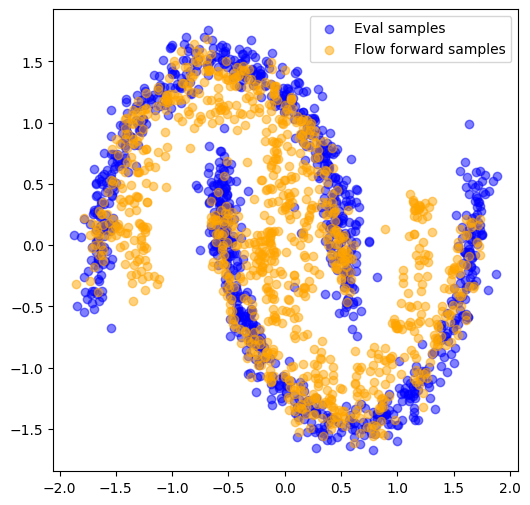

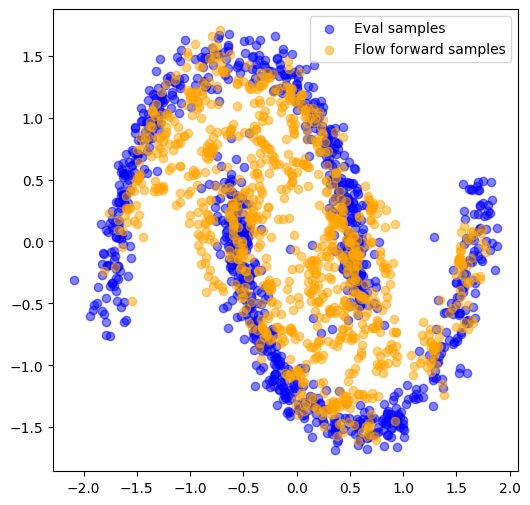

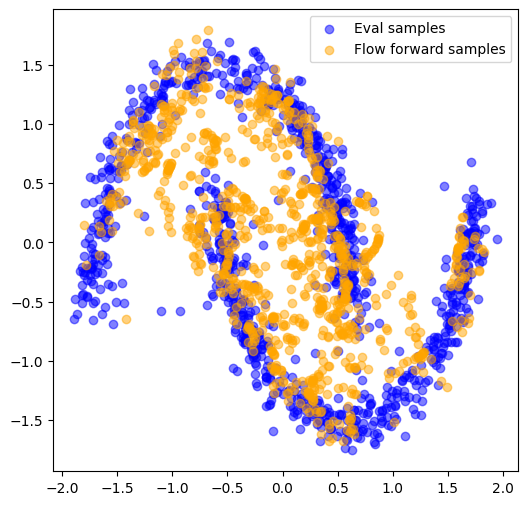

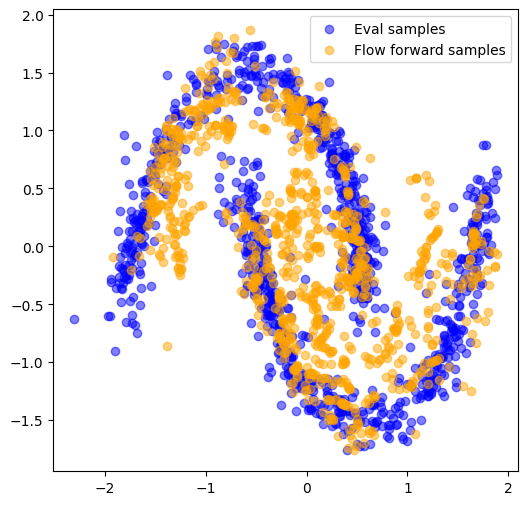

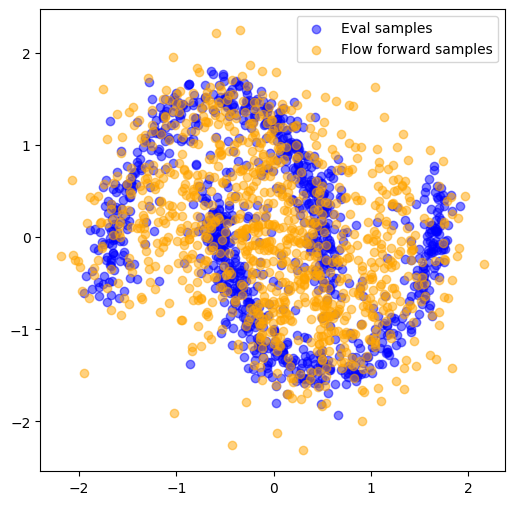

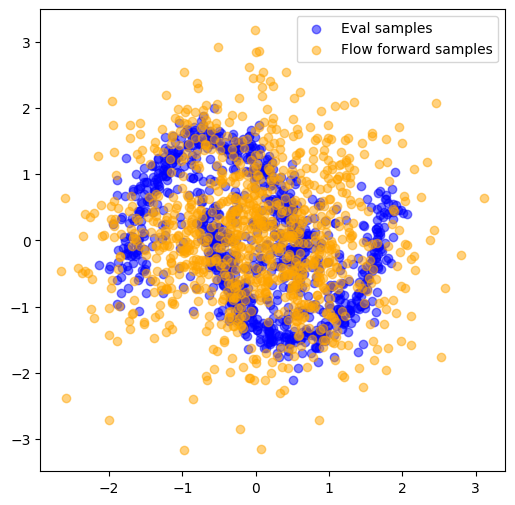

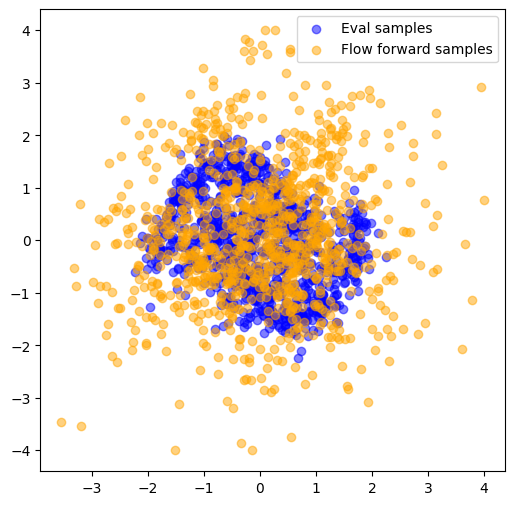

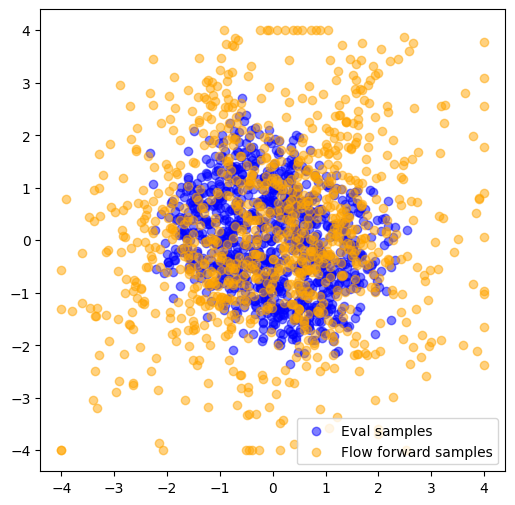

In [72]:
flow_0 = FiLMMLP(input_dim=2, time_dim=1, cond_dim=1, hidden_dim=64).to(device) 
wrapped_flow_0 = WrappedModel(flow_0)
flow_0_weights = torch.load(f'../rebuttal_baselines/cfm_dropout_FiLM_model_0_{i}.pt')
wrapped_flow_0.load_state_dict(flow_0_weights)

flow_1 = FiLMMLP(input_dim=2, time_dim=1, cond_dim=1, hidden_dim=64).to(device)
wrapped_flow_1 = WrappedModel(flow_1)
flow_1_weights = torch.load(f'../rebuttal_baselines/cfm_dropout_FiLM_model_1_{i}.pt')
wrapped_flow_1.load_state_dict(flow_1_weights)

flow_models={0.505: wrapped_flow_0, 0.99: wrapped_flow_1}

model_wass_dists = []
for time_index, lambda_val in index_to_eval_time.items():
    if lambda_val < 0.505:
        base_ambient = t0_ambient
        base_ambient = np.array(base_ambient, dtype=np.float32)
        base_condition = t0_condition
        base_condition = np.array(base_condition, dtype=np.float32)
    else:
        base_ambient = t05_ambient
        base_ambient = np.array(base_ambient, dtype=np.float32)
        base_condition = t05_condition
        base_condition = np.array(base_condition, dtype=np.float32)
    
    flowforward_samples = flow_forward(base_ambient, base_condition, lambda_val, flow_models)

    eval_sample = eval_samples[time_index]
    eval_ambient = eval_sample[:,:2]

    plt.figure(figsize=(6,6))
    plt.scatter(eval_ambient[:,0], eval_ambient[:,1], color='blue', label='Eval samples', alpha=0.5)
    plt.scatter(flowforward_samples[:,0], flowforward_samples[:,1], color='orange', label='Flow forward samples', alpha=0.5)
    plt.legend()
    plt.show()